# Lab Assignment: Data Quality & Data Cleaning for Data Warehouse

**สถานการณ์:** คุณเป็น Data Engineer ของร้านค้าออนไลน์ และได้รับไฟล์ `e_commerce_raw.csv` ที่ต้องเตรียมก่อนโหลดเข้าสู่ Data Warehouse  
**เป้าหมาย:** สำรวจปัญหาคุณภาพข้อมูล ออกแบบกฎการทำความสะอาด และส่งออกข้อมูลที่พร้อมใช้งาน

> ห้ามลบข้อมูลผิดปกติโดยไม่อธิบายเหตุผล ต้องพิจารณา Business Context โดยเฉพาะรายการโปรโมชัน


## ผลลัพธ์การเรียนรู้
1. ตรวจสอบข้อมูลด้วย `info()`, `isnull()`, `describe()` และ `duplicated()`
2. เชื่อมโยงปัญหากับ 6 มิติ: Accuracy, Completeness, Consistency, Uniqueness, Timeliness, Validity
3. จัดการ Missing Values และรูปแบบข้อมูลที่ไม่สอดคล้อง
4. ตรวจจับ Outlier ด้วย IQR และทำ Capping อย่างมีเหตุผล
5. สร้างไฟล์ Clean Data และรายงาน Data Quality ก่อน–หลัง


## 0) เตรียมระบบและอ่านข้อมูล

In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'e_commerce_raw.csv'
OUTPUT_DIR = ROOT / 'outputs' / 'student_submission'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 50)
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print('Shape:', df.shape)
df.head()

Shape: (630, 16)


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,female,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PP,Cancelled,N
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,m,Chanthaburi,05/29/2026,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,COD,Cancelled,N
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,male,Chanthaburi,02/01/2026,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Transfer,Returned,N
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,promptpay,Processing,N


## 1) Data Profiling

ให้แสดงผลต่อไปนี้และเขียนข้อสังเกตใต้เซลล์
- โครงสร้างและชนิดข้อมูล
- จำนวน Missing Values รายคอลัมน์
- สถิติเชิงพรรณนาของข้อมูลตัวเลข
- จำนวนแถวซ้ำทั้งแถว
- จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ


In [21]:
# TODO 1: Data Profiling
# ตัวอย่างคำสั่งที่ควรใช้: df.info(), df.isnull().sum(), df.describe(), df.duplicated().sum()
print("--- 1. Structure & Types ---")
df.info()

print("\n--- 2. Missing Values ---")
print(df.isnull().sum())

print("\n--- 3. Descriptive Statistics ---")
display(df.describe(include='all').T)

print("\n--- 4. Exact Duplicates ---")
print("Duplicate Rows:", df.duplicated().sum())

print("\n--- 5. Unique Values in Categorical Columns ---")
for col in ['Gender', 'Payment_Method', 'Order_Status', 'Is_Promotion']:
    print(f"{col}: {df[col].unique()}")


--- 1. Structure & Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      630 non-null    object 
 1   Customer_ID         630 non-null    object 
 2   Customer_Name       630 non-null    object 
 3   Customer_Email      580 non-null    object 
 4   Gender              630 non-null    object 
 5   Province            618 non-null    object 
 6   Order_Date          630 non-null    object 
 7   Load_Timestamp      630 non-null    object 
 8   Product_Category    630 non-null    object 
 9   Quantity            630 non-null    int64  
 10  Unit_Price          630 non-null    float64
 11  Discount_Rate       630 non-null    float64
 12  Transaction_Amount  630 non-null    float64
 13  Payment_Method      630 non-null    object 
 14  Order_Status        630 non-null    object 
 15  Is_Promotion        630 non-

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction_ID,630,612,T000050,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,630,170,C0179,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Name,630,121,Pim Srisawat,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Email,580,167,jane.chaiyo179@example.com,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,630,10,female,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province,618,8,Nakhon Ratchasima,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,630,365,2026-02-26,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Load_Timestamp,630,553,2026-04-03 17:00:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,630,6,Food,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,630.0,NaN,NaN,NaN,3.660317,4.184784,-3.0,2.0,3.0,5.0,99.0



--- 4. Exact Duplicates ---
Duplicate Rows: 18

--- 5. Unique Values in Categorical Columns ---
Gender: ['female' 'M' 'm' 'male' 'FEMALE' 'Male' 'Female' 'MALE' 'F' 'f']
Payment_Method: ['PP' 'PromptPay' 'COD' 'Transfer' 'promptpay' 'CC' 'bank_transfer'
 'Bank Transfer' 'Credit Card' 'credit card' 'Prompt Pay' 'cash' 'Card'
 'Cash on Delivery']
Order_Status: ['Cancelled' 'Processing' 'Returned' 'Completed' 'Cancel' 'unknown_status'
 'done']
Is_Promotion: ['N' 'Y']


### คำถาม 1
ระบุปัญหาที่พบอย่างน้อย **5 ปัญหา** และจับคู่กับมิติ Data Quality อย่างน้อย **3 มิติ**

| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน/จำนวนแถว |
|---|---|---|---|
| | | | |


## 2) Completeness: จัดการ Missing Values

In [22]:
# TODO 2.1: ตรวจสอบ Customer_Email และ Province ที่หายไป
df['Customer_Email_Was_Missing'] = df['Customer_Email'].isnull()
df['Province_Was_Missing'] = df['Province'].isnull()
# TODO 2.2: ออกแบบวิธีเติม Customer_Email โดยต้องไม่ทำให้แถว Fact หาย
# แนวคิดสำหรับ DW: unknown member / surrogate placeholder และสร้าง flag เพื่อย้อนตรวจสอบได้
df['Customer_Email'] = df.apply(
    lambda row: f"unknown_{row['Customer_ID']}@unknown.local"
    if pd.isnull(row['Customer_Email']) else row['Customer_Email'],
    axis=1
)
# TODO 2.3: เติม Province ที่หายเป็น 'Unknown' พร้อม flag
df['Province'] = df['Province'].fillna('Unknown')


### คำถาม 2
อธิบายว่าเหตุใดการใช้ `dropna()` กับ `Customer_Email` อาจทำให้ยอดขายรวมใน Data Warehouse ผิดเพี้ยน และเหตุใดการเติมค่าเฉลี่ยจึงไม่เหมาะกับข้อมูลประเภทอีเมล


## 3) Consistency: จัดรูปแบบข้อมูลให้เป็นมาตรฐาน

In [24]:
# TODO 3.1: Standardize Gender ให้เหลือ M, F, Unknown
gender_map = {
    'M': 'M',
    'Male': 'M',
    'male': 'M',
    'm': 'M',
    'MALE': 'M',
    'F': 'F',
    'Female': 'F',
    'female': 'F',
    'f': 'F',
    'FEMALE': 'F',
}
df['Gender'] = df['Gender'].map(gender_map).fillna('Unknown')
# TODO 3.2: Standardize Payment_Method ให้เหลือ
# Credit Card, PromptPay, Cash on Delivery, Bank Transfer, Unknown
def clean_payment(val):
    if pd.isna(val):
        return 'Unknown'
    val_str = str(val).lower().strip()
    if 'credit' in val_str or 'card' in val_str or val_str == 'cc':
        return 'Credit Card'
    if 'prompt' in val_str or val_str == 'pp':
        return 'PromptPay'
    if 'cash' in val_str or 'cod' in val_str:
        return 'Cash on Delivery'
    if 'bank' in val_str or 'transfer' in val_str:
        return 'Bank Transfer'
    return 'Unknown'

df['Payment_Method'] = df['Payment_Method'].apply(clean_payment)
# TODO 3.3: แปลง Order_Date ซึ่งมีหลายรูปแบบให้เป็น YYYY-MM-DD
# ระวังความกำกวมระหว่าง DD/MM/YYYY และ MM/DD/YYYY
# ใช้ Load_Timestamp เป็นข้อมูลประกอบ และสร้าง flag สำหรับค่าที่ต้อง fallback/impute
df['Load_Timestamp'] = pd.to_datetime(df['Load_Timestamp'])


def parse_order_date_row(row):
    val = str(row['Order_Date']).strip()
    load_dt = row['Load_Timestamp']

    # ถ้าค่าว่างหรือแปลงไม่ได้ ให้ใช้ Fallback
    if pd.isna(row['Order_Date']) or val in ['', 'nan', 'None', 'NaT']:
        return pd.Series(
            [load_dt.strftime('%Y-%m-%d'), True, 'Fallback_Load_Timestamp']
        )

    try:
        # เช็คว่าขึ้นต้นด้วย YYYY หรือไม่ เพื่อหลีกเลี่ยงการใช้ dayfirst=True กับ ISO format
        if len(val) >= 4 and val[:4].isdigit():
            dt = pd.to_datetime(val)
            parse_method = 'Exact'
        else:
            # ลองใช้ DD/MM/YYYY ก่อน
            dt = pd.to_datetime(val, dayfirst=True)
            parse_method = 'Exact_DayFirst'

            # หาก Order_Date เกิดหลัง Load_Timestamp ให้ลอง MM/DD/YYYY
            if dt > load_dt:
                dt = pd.to_datetime(val, dayfirst=False)
                parse_method = 'Exact_MonthFirst'

        # หากลองแก้แล้ว วันที่ก็ยังมากกว่า Load_Timestamp ให้ Fallback
        if dt > load_dt:
            return pd.Series(
                [load_dt.strftime('%Y-%m-%d'), True, 'Fallback_Load_Timestamp']
            )

        return pd.Series([dt.strftime('%Y-%m-%d'), False, parse_method])

    except Exception:
        return pd.Series(
            [load_dt.strftime('%Y-%m-%d'), True, 'Fallback_Load_Timestamp']
        )


# อัปเดตทั้ง 3 คอลัมน์พร้อมกันจากการคืนค่า pd.Series
df[
    ['Order_Date', 'Order_Date_Was_Imputed', 'Order_Date_Parse_Method']
] = df.apply(parse_order_date_row, axis=1)


### คำถาม 3
ยกตัวอย่าง 1 วันที่สามารถตีความได้ทั้ง DD/MM/YYYY และ MM/DD/YYYY แล้วอธิบายว่าคุณใช้หลักฐานใดช่วยตัดสิน


## 4) Uniqueness: ข้อมูลซ้ำและความซ้ำซ้อนเชิงความหมาย

In [25]:
# TODO 4.1: นับและลบ Exact Duplicates โดยเก็บแถวแรก
exact_dupes = df.duplicated().sum()
df = df.drop_duplicates(keep='first').reset_index(drop=True)
print(f"Removed Exact Duplicates: {exact_dupes}")
# TODO 4.2 (Bonus): ตรวจหาลูกค้าที่ Customer_Email เดียวกัน แต่ Customer_Name เขียนต่างกัน
# อธิบายว่าเหตุใด drop_duplicates() เพียงอย่างเดียวจึงตรวจไม่พบ Near Duplicate
near_dupes = df.groupby('Customer_Email')['Customer_Name'].nunique()
print("\nNear Duplicates Found (Same Email, Multiple Names):")
print(near_dupes[near_dupes > 1])


Removed Exact Duplicates: 18

Near Duplicates Found (Same Email, Multiple Names):
Customer_Email
ploy.saelim47@example.com    2
Name: Customer_Name, dtype: int64


## 5) Accuracy และ Validity: ตรวจสอบกฎธุรกิจ

In [26]:
# TODO 5.1: แปลง Quantity, Unit_Price, Discount_Rate และ Transaction_Amount เป็นตัวเลข
num_cols = ['Quantity', 'Unit_Price', 'Discount_Rate', 'Transaction_Amount']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# TODO 5.2: ตรวจ Quantity ต้องอยู่ในช่วง 1-20
df['Quantity_Was_Invalid'] = ~df['Quantity'].between(1, 20)
# TODO 5.3: คำนวณ Expected_Amount = Quantity * Unit_Price * (1 - Discount_Rate)
# สร้าง Accuracy_Flag เมื่อผลต่างเกิน 1 บาท
df['Expected_Amount'] = df['Quantity'] * df['Unit_Price'] * (1 - df['Discount_Rate'].fillna(0))
df['Accuracy_Flag'] = (df['Transaction_Amount'] - df['Expected_Amount']).abs() > 1.0
# TODO 5.4: Standardize Order_Status และตรวจ Validity
valid_statuses = ['Completed', 'Processing', 'Cancelled', 'Returned']
status_map = {'Cancel': 'Cancelled', 'done': 'Completed'}
df['Order_Status'] = df['Order_Status'].replace(status_map).str.title()
df['Status_Was_Invalid'] = ~df['Order_Status'].isin(valid_statuses)


### คำถาม 4
รายการที่ `Transaction_Amount` ไม่ตรงกับสูตรควรแก้ไขทุกแถวหรือไม่? ให้อธิบายผลของ `Is_Promotion` ต่อการตัดสินใจ


## 6) Outliers: IQR และ Capping/Clipping

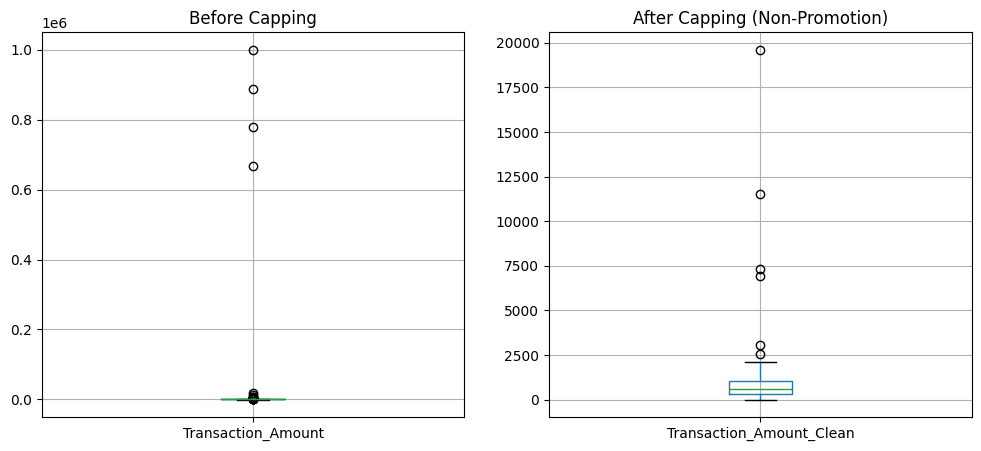

In [27]:
# TODO 6.1: ใช้เฉพาะรายการที่ Is_Promotion != 'Y' คำนวณ Q1, Q3, IQR, Lower Bound, Upper Bound
non_promo_mask = df['Is_Promotion'] != 'Y'
q1 = df.loc[non_promo_mask, 'Transaction_Amount'].quantile(0.25)
q3 = df.loc[non_promo_mask, 'Transaction_Amount'].quantile(0.75)
iqr = q3 - q1
lower_bound = max(0.0, q1 - 1.5 * iqr)
upper_bound = q3 + 1.5 * iqr
# TODO 6.2: สร้าง Outlier Flag ก่อนทำ Capping
df['Outlier_Flag_Before_Capping'] = False
df.loc[non_promo_mask, 'Outlier_Flag_Before_Capping'] = ~df.loc[non_promo_mask, 'Transaction_Amount'].between(lower_bound, upper_bound)
# TODO 6.3: ใช้ .clip() กับ Transaction_Amount เฉพาะรายการที่ไม่ใช่โปรโมชัน
df['Transaction_Amount_Clean'] = df['Transaction_Amount']
df.loc[non_promo_mask, 'Transaction_Amount_Clean'] = df.loc[non_promo_mask, 'Transaction_Amount'].clip(lower=lower_bound, upper=upper_bound)
# TODO 6.4: วาด Boxplot ก่อนและหลัง Capping
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df.boxplot(column='Transaction_Amount', ax=axes[0])
axes[0].set_title('Before Capping')

df.boxplot(column='Transaction_Amount_Clean', ax=axes[1])
axes[1].set_title('After Capping (Non-Promotion)')
plt.show()

df['Transaction_Amount'] = df['Transaction_Amount_Clean']
df.drop(columns=['Transaction_Amount_Clean'], inplace=True)


### คำถาม 5
เพราะเหตุใดข้อมูลที่อยู่นอก IQR Bound จึงไม่จำเป็นต้องเป็นข้อมูลผิดเสมอ? ยกตัวอย่างจาก Dataset นี้


## 7) Timeliness: ความทันเวลาในการโหลดข้อมูล

In [28]:
# TODO 7: คำนวณ Load_Delay_Hours จาก Order_Date ถึง Load_Timestamp
# กำหนด Late เมื่อมากกว่า 24 ชั่วโมง และสรุปจำนวน/ร้อยละ
# 1. แปลงคอลัมน์ Order_Date และ Load_Timestamp ให้เป็น Datetime
df['Order_Date_DT'] = pd.to_datetime(df['Order_Date'])
df['Load_Timestamp_DT'] = pd.to_datetime(df['Load_Timestamp'])

# 2. คำนวณ Load_Delay_Hours (ผลต่างเป็นชั่วโมง)
df['Load_Delay_Hours'] = (
    df['Load_Timestamp_DT'] - df['Order_Date_DT']
).dt.total_seconds() / 3600

# 3. กำหนด Is_Late_Load เมื่อมากกว่า 24 ชั่วโมง
df['Is_Late_Load'] = df['Load_Delay_Hours'] > 24

# 4. สรุปจำนวนและร้อยละ
late_count = df['Is_Late_Load'].sum()
total_count = len(df)
late_percentage = (late_count / total_count) * 100

print('=== สรุปผลการโหลดข้อมูลล่าช้า (Late Load Summary) ===')
print(f'จำนวนรายการทั้งหมด: {total_count:,} รายการ')
print(f'จำนวนรายการที่ Late (> 24 ชั่วโมง): {late_count:,} รายการ')
print(f'คิดเป็นร้อยละ: {late_percentage:.2f}%')

# 5. ลบ Datetime Temporary Columns ออกเพื่อความเป็นระเบียบ
df.drop(columns=['Order_Date_DT', 'Load_Timestamp_DT'], inplace=True)

=== สรุปผลการโหลดข้อมูลล่าช้า (Late Load Summary) ===
จำนวนรายการทั้งหมด: 612 รายการ
จำนวนรายการที่ Late (> 24 ชั่วโมง): 74 รายการ
คิดเป็นร้อยละ: 12.09%


## 8) Data Quality Report และ Export

In [29]:
# TODO 8.1: สรุปตัวชี้วัดก่อนและหลัง Cleaning เป็น DataFrame
# อย่างน้อย: rows, missing email, exact duplicates, invalid dates, mismatched amounts,
# outliers capped, late loads และ invalid statuses
report_data = {
    'Metric': [
        'Total Rows Processed',
        'Exact Duplicates Removed',
        'Missing Customer Email Imputed',
        'Missing Province Imputed',
        'Invalid Quantities Found',
        'Mismatched Transaction Amounts',
        'Invalid Order Statuses',
        'Outliers Capped (Non-Promotion)',
        'Late Loads (>24 Hours)'
    ],
    'Value': [
        len(df),
        exact_dupes,
        df['Customer_Email_Was_Missing'].sum(),
        df['Province_Was_Missing'].sum(),
        df['Quantity_Was_Invalid'].sum(),
        df['Accuracy_Flag'].sum(),
        df['Status_Was_Invalid'].sum(),
        df['Outlier_Flag_Before_Capping'].sum(),
        df['Is_Late_Load'].sum()
    ]
}
quality_report = pd.DataFrame(report_data)
display(quality_report)
# TODO 8.2: Export
# df.to_csv(OUTPUT_DIR / 'e_commerce_clean.csv', index=False, encoding='utf-8-sig')
# report.to_csv(OUTPUT_DIR / 'data_quality_report.csv', index=False, encoding='utf-8-sig')
df.to_csv(OUTPUT_DIR / 'e_commerce_clean.csv', index=False, encoding='utf-8-sig')
quality_report.to_csv(OUTPUT_DIR / 'data_quality_report.csv', index=False, encoding='utf-8-sig')
print("Export completed successfully!")


,Metric,Value
0,Total Rows Processed,612
1,Exact Duplicates Removed,18
2,Missing Customer Email Imputed,48
3,Missing Province Imputed,12
4,Invalid Quantities Found,3
5,Mismatched Transaction Amounts,50
6,Invalid Order Statuses,5
7,Outliers Capped (Non-Promotion),21
8,Late Loads (>24 Hours),74


Export completed successfully!


## 9) Reflection

1. **ขั้นตอนที่เสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุด:**

    คือขั้นตอน **Data Deletion / Dropping** โดยเฉพาะการใช้ `dropna()` กับคอลัมน์ที่ไม่ใช่ Primary Key (เช่น `Customer_Email`) และการลบแถว Outlier ทิ้งทันที เพราะจะทำให้แถวรายการธุรกรรมที่มีการซื้อขายและเกิดรายได้จริงถูกลบออกจากระบบ ส่งผลให้ยอดขายรวมใน Data Warehouse ต่ำกว่าความเป็นจริง

2. **กฎที่ควรนำไปทำ Automation ใน Data Pipeline:**
    
    คือ **การจัดมาตรฐานรูปแบบวันที่ (Date Standardization)** ให้เป็น `YYYY-MM-DD` และ **การสร้าง Validation Rules ตรวจสอบข้อมูลก่อนตักเข้า Data Warehouse** เช่น การเช็ก Regex ของรูปแบบอีเมล และการตรวจสอบความถูกต้องของ `Transaction_Amount` ร่วมกับเงื่อนไข `Is_Promotion`

3. **3 Expectations ที่ควรสร้างด้วย Great Expectations:**
* `expect_column_values_to_not_be_null(column="Transaction_ID")` — ตรวจสอบว่า Primary Key ห้ามเป็นค่าว่าง (Completeness)
* `expect_column_values_to_match_regex(column="Customer_Email", regex=r"^[\w\.-]+@[\w\.-]+\.\w+$")` — ตรวจสอบโครงสร้างอีเมลให้ถูกต้องตามรูปแบบ (Validity)
* `expect_column_values_to_be_between(column="Unit_Price", min_value=0)` — ตรวจสอบว่าราคาสินค้าต้องไม่เป็นค่าติดลบ (Consistency & Accuracy)




## Checklist ก่อนส่ง
- [ ] Notebook รันจากบนลงล่างได้โดยไม่ Error
- [ ] มีคำตอบคำถามทั้ง 5 ข้อและ Reflection
- [ ] ส่ง `e_commerce_clean.csv`
- [ ] ส่ง `data_quality_report.csv`
- [ ] ไม่ลบรายการโปรโมชันเพียงเพราะเป็น Outlier
